# TASK 3 — Cleaning Data

## Retail Store Sales Data Cleaning

### Objective
Demonstrate professional-level data cleaning skills by identifying and correcting
missing values, duplicate records, inconsistent formatting, incorrect data types,
and numerical outliers.

### Dataset
Retail Store Sales: Dirty for Data Cleaning

### Tools
- Python
- Pandas
- NumPy
- Jupyter Notebook

### Cleaning Workflow
1. Load and inspect the dataset
2. Generate a data quality report
3. Handle missing values
4. Remove duplicate records
5. Standardize inconsistent formatting
6. Detect and handle outliers
7. Correct data types
8. Validate the cleaned dataset
9. Compare before vs. after quality
10. Save the cleaned CSV

## 1. Dataset Description

The dataset contains retail sales transactions.

Each row represents a transaction and includes information about:
- Transaction ID
- Customer ID
- Product category
- Item
- Price per unit
- Quantity
- Total amount spent
- Payment method
- Location
- Transaction date
- Discount status

The dataset is intentionally imperfect and contains missing values and incomplete
transaction information, making it appropriate for practicing real-world data
cleaning techniques.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Raw Dataset

The original CSV file is loaded from the `data/raw` folder.
The raw dataset is preserved so that all cleaning operations can be compared
against the original data.

In [6]:
import pandas as pd

file_path = r"C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 3 - Data Cleaning\data\raw\retail_store_sales.csv"

df = pd.read_csv(file_path)


print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 12575
Columns: 11


In [7]:
df_raw = df.copy()

print("Raw dataset backup created.")

Raw dataset backup created.


## 3. Initial Data Inspection

The first few records are displayed to understand the structure and contents
of the raw dataset.

In [8]:
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [9]:
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12575
Number of columns: 11


In [11]:
print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- Transaction ID
- Customer ID
- Category
- Item
- Price Per Unit
- Quantity
- Total Spent
- Payment Method
- Location
- Transaction Date
- Discount Applied


## 4. Initial Data Types

The data types of all columns are inspected before cleaning.
This helps identify columns that need conversion, such as transaction dates and
numeric variables.

In [12]:
df.dtypes

Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied     object
dtype: object

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction ID,12575,12575,TXN_6867343,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,12575,25,CUST_05,544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,12575,8,Furniture,1591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,11362,200,Item_2_BEV,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price Per Unit,11966.0,NaN,NaN,NaN,23.365912,10.743519,5.0,14.0,23.0,33.5,41.0
Quantity,11971.0,NaN,NaN,NaN,5.53638,2.857883,1.0,3.0,6.0,8.0,10.0
Total Spent,11971.0,NaN,NaN,NaN,129.652577,94.750697,5.0,51.0,108.5,192.0,410.0
Payment Method,12575,3,Cash,4310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,12575,2,Online,6354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction Date,12575,1114,2022-05-30,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Quality Report — Before Cleaning

Before modifying the dataset, a data quality report is generated to identify:
- Missing values
- Duplicate records
- Data types
- Unique values
- Numerical ranges
- Potential invalid numerical values

In [15]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(2).values,
    "Unique Values": df.nunique(dropna=True).values
})

quality_report

,Column,Data Type,Missing Values,Missing %,Unique Values
0,Transaction ID,str,0,0.00,12575
1,Customer ID,str,0,0.00,25
2,Category,str,0,0.00,8
3,Item,str,1213,9.65,200
4,Price Per Unit,float64,609,4.84,25
5,Quantity,float64,604,4.80,10
6,Total Spent,float64,604,4.80,227
7,Payment Method,str,0,0.00,3
8,Location,str,0,0.00,2
9,Transaction Date,str,0,0.00,1114


In [16]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 7229


In [17]:
duplicate_count_before = df.duplicated().sum()

print("Duplicate rows:", duplicate_count_before)

Duplicate rows: 0


In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

range_report = pd.DataFrame({
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Mean": df[numeric_columns].mean().round(2),
    "Median": df[numeric_columns].median().round(2)
})

range_report

,Minimum,Maximum,Mean,Median
Price Per Unit,5.0,41.0,23.37,23.0
Quantity,1.0,10.0,5.54,6.0
Total Spent,5.0,410.0,129.65,108.5


In [19]:
print("Negative values:")

for col in numeric_columns:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count}")

Negative values:
Price Per Unit: 0
Quantity: 0
Total Spent: 0


In [20]:
print("Quantity range:")
print("Minimum:", df["Quantity"].min())
print("Maximum:", df["Quantity"].max())

print("\nPrice Per Unit range:")
print("Minimum:", df["Price Per Unit"].min())
print("Maximum:", df["Price Per Unit"].max())

print("\nTotal Spent range:")
print("Minimum:", df["Total Spent"].min())
print("Maximum:", df["Total Spent"].max())

Quantity range:
Minimum: 1.0
Maximum: 10.0

Price Per Unit range:
Minimum: 5.0
Maximum: 41.0

Total Spent range:
Minimum: 5.0
Maximum: 410.0


In [21]:
categorical_columns = [
    "Category",
    "Payment Method",
    "Location",
    "Discount Applied"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Category ---
Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

--- Payment Method ---
Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

--- Location ---
Location
Online      6354
In-store    6221
Name: count, dtype: int64

--- Discount Applied ---
Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64


## 6. Missing Data Handling Strategy

The missing-value treatment is selected according to the meaning of each column.

| Column | Strategy | Reason |
|---|---|---|
| Item | Mode / logical reconstruction | Item is categorical |
| Price Per Unit | Category-wise median | Price is numerical and may contain outliers |
| Quantity | Median | Quantity is numerical and should remain robust to extreme values |
| Total Spent | Calculate from Quantity × Price when possible; otherwise median | Total spending has a logical relationship with price and quantity |
| Payment Method | Mode | Categorical variable |
| Location | Mode | Categorical variable |
| Discount Applied | Mode | Boolean/categorical variable |
| Transaction Date | No imputation if already complete | Transaction date is an important identifier for the transaction |
| Transaction ID | No imputation | Identifier should not be artificially generated |
| Customer ID | No imputation | Customer identifier should not be fabricated |
| Category | No arbitrary imputation | Category is important for interpreting the transaction |

In [22]:
df = df.replace(
    ["None", "none", "NULL", "null", "NA", "N/A", "", " "],
    np.nan
)

print("Missing-value representations standardized.")

Missing-value representations standardized.


### 6.1 Convert Numeric Columns

Numeric columns are explicitly converted to numeric types. Invalid values are
converted to NaN so that they can be handled consistently during cleaning.

In [23]:
numeric_cols = [
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_cols].dtypes)

Price Per Unit    float64
Quantity          float64
Total Spent       float64
dtype: object


In [24]:
item_mode = df["Item"].mode()[0]

df["Item"] = df["Item"].fillna(item_mode)

print("Missing Item values filled using mode.")
print("Item mode used:", item_mode)

Missing Item values filled using mode.
Item mode used: Item_2_BEV


In [25]:
df["Price Per Unit"] = (
    df.groupby("Category")["Price Per Unit"]
      .transform(lambda x: x.fillna(x.median()))
)

print("Missing Price Per Unit values filled using category-wise median.")

Missing Price Per Unit values filled using category-wise median.


In [26]:
df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)

print("Missing Quantity values filled using median.")

Missing Quantity values filled using median.


In [27]:
mask_total = (
    df["Total Spent"].isna()
    & df["Quantity"].notna()
    & df["Price Per Unit"].notna()
)

df.loc[mask_total, "Total Spent"] = (
    df.loc[mask_total, "Quantity"]
    * df.loc[mask_total, "Price Per Unit"]
)

print("Total Spent reconstructed where Quantity and Price were available.")

Total Spent reconstructed where Quantity and Price were available.


In [28]:
remaining_total_missing = df["Total Spent"].isna().sum()

print("Remaining missing Total Spent values:", remaining_total_missing)

Remaining missing Total Spent values: 0


In [29]:
df["Payment Method"] = df["Payment Method"].fillna(
    df["Payment Method"].mode()[0]
)

In [30]:
df["Location"] = df["Location"].fillna(
    df["Location"].mode()[0]
)

In [31]:
df["Discount Applied"] = df["Discount Applied"].fillna(
    df["Discount Applied"].mode()[0]
)

## 7. Missing Values After Imputation

The missing-value counts are checked again after applying the selected
imputation strategies.

In [32]:
missing_after_imputation = df.isnull().sum()

print(missing_after_imputation)
print("\nTotal remaining missing values:",
      missing_after_imputation.sum())

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Total remaining missing values: 0


## 8. Duplicate Removal

Duplicate rows can cause transactions to be counted more than once.

The number of duplicate rows is calculated before removal and then all exact
duplicate rows are removed using `drop_duplicates()`.

In [33]:
duplicate_count_before = df.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count_before)

df = df.drop_duplicates().copy()

duplicate_count_after = df.duplicated().sum()

print("Duplicate rows after removal:", duplicate_count_after)

Duplicate rows before removal: 0
Duplicate rows after removal: 0


In [34]:
duplicate_transaction_ids = df["Transaction ID"].duplicated().sum()

print("Duplicate Transaction IDs:", duplicate_transaction_ids)

Duplicate Transaction IDs: 0


## 9. Standardization of Text Formatting

Text fields are standardized by:
- Removing leading and trailing spaces
- Converting repeated whitespace into a single space
- Standardizing known categorical representations
- Preserving meaningful category names

The objective is to ensure that values such as `Cash`, ` cash ` and `CASH`
would be treated consistently without changing the meaning of the data.

In [35]:
text_columns = [
    "Transaction ID",
    "Customer ID",
    "Category",
    "Item",
    "Payment Method",
    "Location"
]

for col in text_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

print("Text formatting standardized.")

Text formatting standardized.


In [36]:
payment_mapping = {
    "cash": "Cash",
    "CASH": "Cash",
    "credit card": "Credit Card",
    "CREDIT CARD": "Credit Card",
    "digital wallet": "Digital Wallet",
    "DIGITAL WALLET": "Digital Wallet"
}

df["Payment Method"] = (
    df["Payment Method"]
    .replace(payment_mapping)
)

print(df["Payment Method"].unique())

<StringArray>
['Digital Wallet', 'Credit Card', 'Cash']
Length: 3, dtype: string


In [37]:
location_mapping = {
    "online": "Online",
    "ONLINE": "Online",
    "in-store": "In-store",
    "IN-STORE": "In-store"
}

df["Location"] = (
    df["Location"]
    .replace(location_mapping)
)

print(df["Location"].unique())

<StringArray>
['Online', 'In-store']
Length: 2, dtype: string


In [38]:
category_mapping = {
    "food": "Food",
    "FOOD": "Food",
    "patisserie": "Patisserie",
    "PATISSERIE": "Patisserie",
    "butchers": "Butchers",
    "BUTCHERS": "Butchers",
    "beverages": "Beverages",
    "BEVERAGES": "Beverages",
    "milk products": "Milk Products",
    "MILK PRODUCTS": "Milk Products",
    "furniture": "Furniture",
    "FURNITURE": "Furniture",
    "electric household essentials": "Electric household essentials",
    "ELECTRIC HOUSEHOLD ESSENTIALS": "Electric household essentials",
    "computers and electric accessories": "Computers and electric accessories",
    "COMPUTERS AND ELECTRIC ACCESSORIES": "Computers and electric accessories"
}

df["Category"] = df["Category"].replace(category_mapping)

print(df["Category"].unique())

<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: string


## 10. Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify unusually high or low
values in numerical columns.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside these limits are flagged as potential outliers.

An outlier is not automatically an error. It must be evaluated in context before
being removed or modified.

In [39]:
def detect_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (
        (data[column] < lower_bound)
        | (data[column] > upper_bound)
    )
    
    return {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_mask.sum()
    }

In [40]:
outlier_results = {}

for col in ["Price Per Unit", "Quantity", "Total Spent"]:
    outlier_results[col] = detect_iqr_outliers(df, col)

outlier_report = pd.DataFrame(outlier_results).T

outlier_report

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
Price Per Unit,14.0,32.0,18.0,-13.0,59.0,0.0
Quantity,3.0,8.0,5.0,-4.5,15.5,0.0
Total Spent,52.0,192.0,140.0,-158.0,402.0,60.0


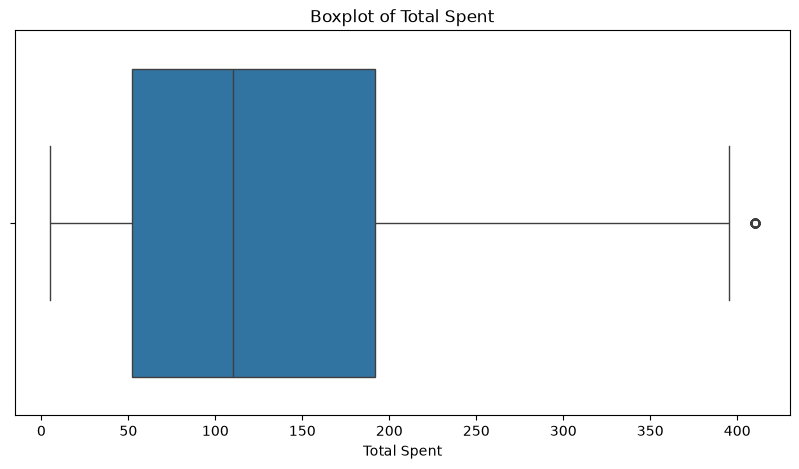

In [41]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Total Spent"])

plt.title("Boxplot of Total Spent")
plt.xlabel("Total Spent")

plt.show()

### Outlier Treatment Decision

The IQR method identifies potential outliers in numerical columns.

Potential outliers are not automatically removed because a high transaction value
can represent a legitimate purchase rather than a data-entry error.

The `Total Spent` column is also logically related to:

    Total Spent = Quantity × Price Per Unit

Therefore, valid high-value transactions are retained.

Only values that are demonstrably impossible, such as negative price, negative
quantity, negative total spending, or mathematically inconsistent records, should
be corrected or removed.

Decision: **Retain legitimate IQR outliers and document them rather than
artificially deleting valid transactions.**

In [42]:
df["Calculated Total"] = (
    df["Quantity"] * df["Price Per Unit"]
)

df["Total Difference"] = (
    df["Total Spent"] - df["Calculated Total"]
)

print(
    "Rows with Total Spent mismatch:",
    (df["Total Difference"].abs() > 0.01).sum()
)

Rows with Total Spent mismatch: 584


In [43]:
valid_calculation = (
    df["Quantity"].notna()
    & df["Price Per Unit"].notna()
)

df.loc[valid_calculation, "Total Spent"] = (
    df.loc[valid_calculation, "Quantity"]
    * df.loc[valid_calculation, "Price Per Unit"]
)

print("Total Spent validated using Quantity × Price Per Unit.")

Total Spent validated using Quantity × Price Per Unit.


In [44]:
df = df.drop(
    columns=["Calculated Total", "Total Difference"],
    errors="ignore"
)

print("Temporary validation columns removed.")

Temporary validation columns removed.


## 11. Data Type Correction

The final dataset must use appropriate data types.

- Transaction ID → string
- Customer ID → string
- Category → string
- Item → string
- Price Per Unit → float
- Quantity → float
- Total Spent → float
- Payment Method → string
- Location → string
- Transaction Date → datetime
- Discount Applied → boolean

In [45]:
df["Transaction ID"] = df["Transaction ID"].astype("string")
df["Customer ID"] = df["Customer ID"].astype("string")

In [46]:
df["Price Per Unit"] = df["Price Per Unit"].astype(float)
df["Total Spent"] = df["Total Spent"].astype(float)

In [47]:
df["Quantity"] = df["Quantity"].astype(float)

In [48]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

print(df["Transaction Date"].dtype)

datetime64[us]


In [49]:
df["Discount Applied"] = (
    df["Discount Applied"]
    .astype("boolean")
)

In [50]:
df.dtypes

Transaction ID              string
Customer ID                 string
Category                    string
Item                        string
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              string
Location                    string
Transaction Date    datetime64[us]
Discount Applied           boolean
dtype: object

## 12. Final Data Quality Validation

The cleaned dataset is checked for:
- Remaining missing values
- Duplicate records
- Correct data types
- Invalid numerical values
- Invalid dates
- Transaction-total consistency

In [51]:
print("Remaining missing values:")
print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())

print("\nDuplicate rows:",
      df.duplicated().sum())

Remaining missing values:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Total missing values: 0

Duplicate rows: 0


In [52]:
for col in ["Price Per Unit", "Quantity", "Total Spent"]:
    print(
        f"{col} negative values:",
        (df[col] < 0).sum()
    )

Price Per Unit negative values: 0
Quantity negative values: 0
Total Spent negative values: 0


In [53]:
print(
    "Invalid/missing transaction dates:",
    df["Transaction Date"].isna().sum()
)

Invalid/missing transaction dates: 0


In [54]:
calculated_total = (
    df["Quantity"] * df["Price Per Unit"]
)

mismatch_count = (
    (df["Total Spent"] - calculated_total).abs() > 0.01
).sum()

print("Transaction total mismatches:", mismatch_count)

Transaction total mismatches: 0


In [55]:
before_rows = df_raw.shape[0]
before_columns = df_raw.shape[1]

before_nulls = df_raw.isnull().sum().sum()
before_duplicates = df_raw.duplicated().sum()

before_dtype_accuracy = "Needs correction"

In [56]:
after_rows = df.shape[0]
after_columns = df.shape[1]

after_nulls = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()

after_dtype_accuracy = "Verified"

In [57]:
summary_table = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Column Count",
        "Total Null Count",
        "Duplicate Row Count",
        "Data Type Accuracy"
    ],
    
    "Before Cleaning": [
        before_rows,
        before_columns,
        before_nulls,
        before_duplicates,
        before_dtype_accuracy
    ],
    
    "After Cleaning": [
        after_rows,
        after_columns,
        after_nulls,
        after_duplicates,
        after_dtype_accuracy
    ]
})

summary_table

,Metric,Before Cleaning,After Cleaning
0,Row Count,12575,12575
1,Column Count,11,11
2,Total Null Count,7229,0
3,Duplicate Row Count,0,0
4,Data Type Accuracy,Needs correction,Verified


In [58]:
rows_removed = before_rows - after_rows

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", rows_removed)

Rows before cleaning: 12575
Rows after cleaning: 12575
Rows removed: 0


In [59]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Price Per Unit,12575.0,23.382664,5.0,14.0,23.0,32.0,41.0,10.485808
Quantity,12575.0,5.558648,1.0,3.0,6.0,8.0,10.0,2.79016
Total Spent,12575.0,130.308429,5.0,55.0,110.0,192.0,410.0,92.422919
Transaction Date,12575,2023-07-12 20:23:41.105367,2022-01-01 00:00:00,2022-09-30 00:00:00,2023-07-13 00:00:00,2024-04-24 00:00:00,2025-01-18 00:00:00,NaN


In [60]:
for col in ["Category", "Payment Method", "Location"]:
    print(f"\n{col}:")
    print(df[col].unique())


Category:
<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: string

Payment Method:
<StringArray>
['Digital Wallet', 'Credit Card', 'Cash']
Length: 3, dtype: string

Location:
<StringArray>
['Online', 'In-store']
Length: 2, dtype: string


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  string        
 1   Customer ID       12575 non-null  string        
 2   Category          12575 non-null  string        
 3   Item              12575 non-null  string        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  string        
 8   Location          12575 non-null  string        
 9   Transaction Date  12575 non-null  datetime64[us]
 10  Discount Applied  12575 non-null  boolean       
dtypes: boolean(1), datetime64[us](1), float64(3), string(6)
memory usage: 1007.1 KB


## 13. Save the Cleaned Dataset

The cleaned dataset is saved as a separate CSV file.

The original raw dataset is preserved and is not overwritten.

In [63]:
import os

processed_folder = r"C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 3 - Data Cleaning\data\processed"

os.makedirs(processed_folder, exist_ok=True)

print("Processed folder created successfully.")

Processed folder created successfully.


In [64]:
output_path = r"C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 3 - Data Cleaning\data\processed\retail_store_sales_cleaned.csv"

df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print("File:", output_path)

Cleaned dataset saved successfully.
File: C:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 3 - Data Cleaning\data\processed\retail_store_sales_cleaned.csv


In [65]:
import os

print(
    "File exists:",
    os.path.exists(output_path)
)

print(
    "File size:",
    round(os.path.getsize(output_path) / 1024, 2),
    "KB"
)

File exists: True
File size: 1200.16 KB


In [66]:
df_check = pd.read_csv(
    output_path,
    parse_dates=["Transaction Date"]
)

print("Cleaned CSV reloaded successfully.")
print("Shape:", df_check.shape)

Cleaned CSV reloaded successfully.
Shape: (12575, 11)


In [67]:
print("Missing values:",
      df_check.isnull().sum().sum())

print("Duplicate rows:",
      df_check.duplicated().sum())

print("\nData types:")
print(df_check.dtypes)

Missing values: 0
Duplicate rows: 0

Data types:
Transaction ID                 str
Customer ID                    str
Category                       str
Item                           str
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
Discount Applied              bool
dtype: object


## 14. Final Observations

### Data Cleaning Summary

The retail sales dataset was systematically cleaned using Pandas and NumPy.

The following operations were performed:

1. The raw dataset was loaded and preserved separately.
2. A data quality report was generated before cleaning.
3. Missing values were identified column-wise.
4. Appropriate imputation strategies were selected based on the meaning of each
   variable.
5. Missing categorical values were handled using mode-based imputation.
6. Numerical values were handled using median-based imputation where appropriate.
7. Total spending was reconstructed using Quantity × Price Per Unit whenever
   sufficient information was available.
8. Duplicate rows were identified and removed.
9. Text fields were standardized by removing unnecessary whitespace and
   normalizing known categorical representations.
10. Potential numerical outliers were identified using the IQR method.
11. Legitimate high-value transactions were retained rather than automatically
    deleting statistically unusual but valid observations.
12. Transaction dates were converted to datetime format.
13. Identifier columns were converted to string format.
14. Monetary columns were converted to floating-point format.
15. Final validation was performed for missing values, duplicates, numerical
    validity, date validity, and transaction-total consistency.
16. The cleaned dataset was saved as a new CSV file without modifying the
    original raw dataset.

### Result

The resulting CSV is ready for downstream analysis and contains standardized
data types, cleaned missing values, validated numerical fields, and documented
data-quality decisions.